# Notebook 04 - Raster data cleaning

This notebook processes the per-period weighted overlay GeoPackages produced by notebook 03  
and reclassifies the continuous `mean` score into **6 standard-deviation bands**, then collapses  
those into **3 classes** (Low / Medium / High) – one classification per time period.

**Inputs:** `../results/metrics/overlay_output/weighted_overlay_clusters_{period}.gpkg`  
**Outputs:** `../data/processed/classified_gt/classified_{period}.gpkg`

> Note: μ and σ are computed independently for each period.

In [1]:
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
#PERIODS = ['1990_2000', '2000_2010', '2010_2020']
PERIODS = ['1990_2020']

OVERLAY_DIR   = Path('../results/metrics/overlay_output')
CLASSIFIED_DIR = Path('../data/processed/classified_gt')

os.makedirs(CLASSIFIED_DIR, exist_ok=True)
print('Output directory:', CLASSIFIED_DIR.resolve())

Output directory: C:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\data\processed\classified_gt


## Classify each time period

For each period:
1. Load the weighted overlay GeoPackage
2. Compute per-period μ and σ on the `mean` column
3. Cut into 6 σ-bands → `mean_sd_class` (label) and `mean_sd_class_idx` (0–5)
4. Collapse 6 → 3 classes: {0,1}→0 Low, {2,3}→1 Medium, {4,5}→2 High
5. Save classified GeoPackage

In [3]:
results_summary = []

for period in PERIODS:
    gpkg_path = OVERLAY_DIR / f'weighted_overlay_clusters_{period}.gpkg'
    if not gpkg_path.exists():
        print(f'[SKIP] {period}: file not found ({gpkg_path})')
        continue

    # --- Load ---
    layers = fiona.listlayers(str(gpkg_path))
    gdf = gpd.read_file(str(gpkg_path), layer=layers[0])

    # Normalise column name: '_mean' → 'mean'
    if '_mean' in gdf.columns and 'mean' not in gdf.columns:
        gdf = gdf.rename(columns={'_mean': 'mean'})

    if 'mean' not in gdf.columns:
        raise KeyError(f"Period {period}: column 'mean' not found. Available: {list(gdf.columns)}")

    # --- 6-class σ binning ---
    vals = pd.to_numeric(gdf['mean'], errors='coerce')
    mu    = vals.mean(skipna=True)
    sigma = vals.std(skipna=True)

    bins = [-np.inf,
            mu - 2*sigma, mu - 1*sigma,
            mu,
            mu + 1*sigma, mu + 2*sigma,
            np.inf]
    labels_6 = [
        '<= mu-2σ (very low)',
        '(mu-2σ, mu-1σ] (low)',
        '(mu-1σ, mu] (slightly low)',
        '(mu, mu+1σ] (slightly high)',
        '(mu+1σ, mu+2σ] (high)',
        '> mu+2σ (very high)'
    ]

    gdf['mean_sd_class']     = pd.cut(vals, bins=bins, labels=labels_6)
    gdf['mean_sd_class_idx'] = pd.cut(vals, bins=bins, labels=False)

    # --- Collapse 6 → 3 classes ---
    map_6to3  = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
    label_map = {0: 'Low', 1: 'Medium', 2: 'High'}

    idx6 = pd.to_numeric(gdf['mean_sd_class_idx'], errors='coerce')
    gdf['mean_sd_class3_idx'] = idx6.map(map_6to3)
    gdf['mean_sd_class3']     = gdf['mean_sd_class3_idx'].map(label_map)

    # Overwrite 6-class index with 3-class index (matches OLD notebook behaviour)
    gdf['mean_sd_class_idx'] = gdf['mean_sd_class3_idx']

    # --- Save ---
    out_path = CLASSIFIED_DIR / f'classified_{period}.gpkg'
    gdf.to_file(str(out_path), driver='GPKG')

    counts = gdf['mean_sd_class3'].value_counts(dropna=False)
    print(f'{period}  μ={mu:.4f}  σ={sigma:.4f}  → {dict(counts)}')
    print(f'  Saved: {out_path}')

    results_summary.append({
        'period': period,
        'mu': mu,
        'sigma': sigma,
        'n_rows': len(gdf),
        'Low':    int(counts.get('Low',    0)),
        'Medium': int(counts.get('Medium', 0)),
        'High':   int(counts.get('High',   0)),
    })

print('\nDone. Files written to:', CLASSIFIED_DIR.resolve())

1990_2020  μ=3.2015  σ=0.4887  → {'Medium': np.int64(1533), 'High': np.int64(358), 'Low': np.int64(341)}
  Saved: ..\data\processed\classified_gt\classified_1990_2020.gpkg

Done. Files written to: C:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\data\processed\classified_gt


## Summary table

In [4]:
summary_df = pd.DataFrame(results_summary)
summary_df

,period,mu,sigma,n_rows,Low,Medium,High
0,1990_2020,3.201538,0.488662,2232,341,1533,358


## Class distribution per period

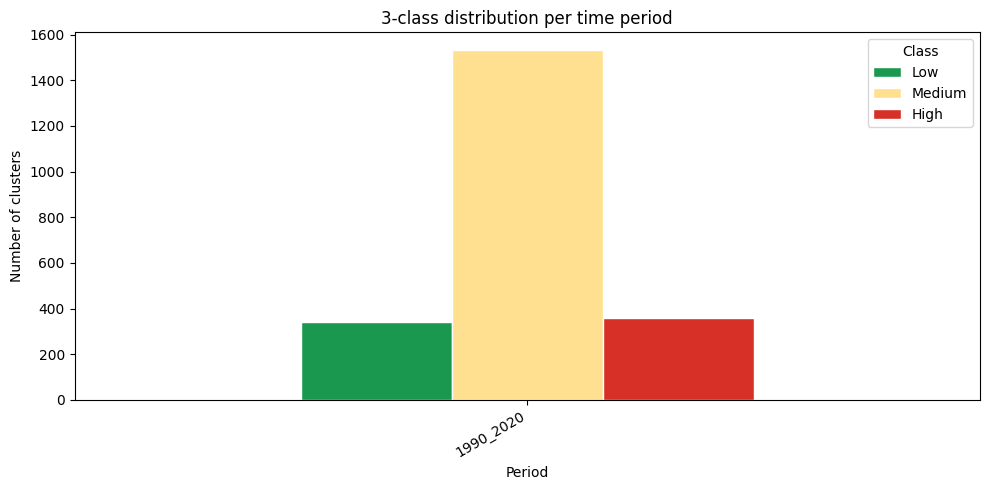

In [5]:
if results_summary:
    df_plot = pd.DataFrame(results_summary).set_index('period')[['Low', 'Medium', 'High']]
    ax = df_plot.plot(
        kind='bar',
        figsize=(10, 5),
        color=['#1a9850', '#fee090', '#d73027'],
        edgecolor='white'
    )
    ax.set_title('3-class distribution per time period')
    ax.set_xlabel('Period')
    ax.set_ylabel('Number of clusters')
    ax.set_xticklabels(df_plot.index, rotation=30, ha='right')
    ax.legend(title='Class')
    plt.tight_layout()
    plt.show()

## Spatial preview — last period

C:\Users\jonas\AppData\Local\Temp\ipykernel_6556\292845934.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Class', loc='upper left')
C:\Users\jonas\AppData\Local\Temp\ipykernel_6556\292845934.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Class', loc='upper left')


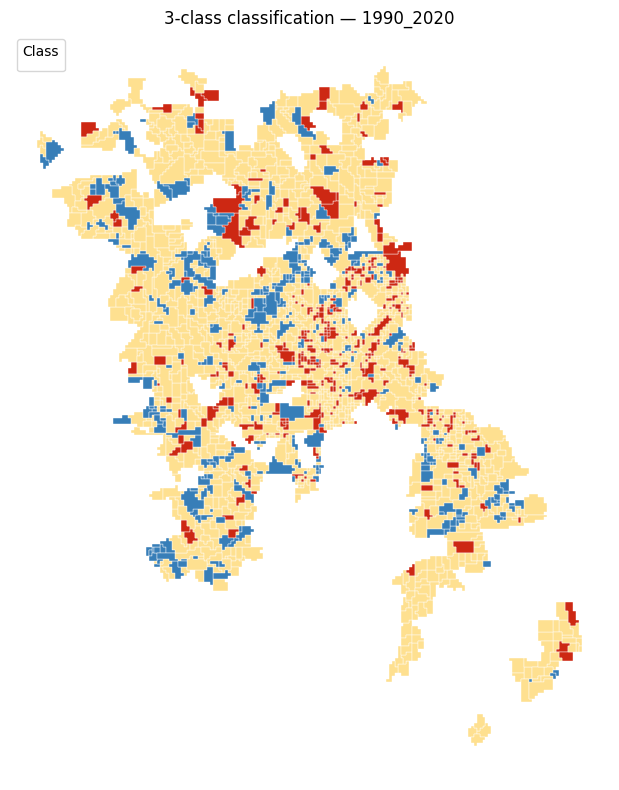

In [6]:
if results_summary:
    last_period = results_summary[-1]['period']
    gdf_preview = gpd.read_file(str(CLASSIFIED_DIR / f'classified_{last_period}.gpkg'))

    color_map = {'Low': "#cd2813", 'Medium': '#fee090', 'High': "#377eb8"}
    gdf_preview['color'] = gdf_preview['mean_sd_class3'].map(color_map).fillna('#cccccc')

    fig, ax = plt.subplots(figsize=(8, 8))
    for cls, color in color_map.items():
        subset = gdf_preview[gdf_preview['mean_sd_class3'] == cls]
        if not subset.empty:
            subset.plot(ax=ax, color=color, label=cls, edgecolor='white', linewidth=0.3)
    ax.set_title(f'3-class classification — {last_period}')
    ax.legend(title='Class', loc='upper left')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

## Combined classification across all periods

Rules applied per cluster:
- If the cluster was **ever class 0 (Low)** in any period → locked at **0** (gentrified areas stack)
- Otherwise → compute the **mean of the `mean` column across all periods** for that cluster, then threshold at the grand mean of those averages:
  - at or below grand mean → **1 (Medium)**
  - above grand mean → **2 (High)**

Output: `../data/processed/classified_gt/classified_combined.gpkg`

In [7]:
# --- Load all classified GeoPackages ---
all_gdfs = {}
for period in PERIODS:
    path = CLASSIFIED_DIR / f'classified_{period}.gpkg'
    if path.exists():
        all_gdfs[period] = gpd.read_file(str(path))
    else:
        print(f'[SKIP] {period}: file not found')

if not all_gdfs:
    raise RuntimeError('No classified GeoPackages found. Run the classification loop first.')

# Determine join key
first_gdf = list(all_gdfs.values())[0]
if 'munic_clus' in first_gdf.columns:
    join_key = 'munic_clus'
elif 'cluster_id' in first_gdf.columns:
    join_key = 'cluster_id'
else:
    raise KeyError(f'No suitable join key found. Available columns: {list(first_gdf.columns)}')

print(f'Using join key: {join_key!r}')

# --- Build long-format table: cluster × period ---
records = []
for period, gdf_p in all_gdfs.items():
    tmp = gdf_p[[join_key, 'mean', 'mean_sd_class3_idx']].copy()
    tmp['period'] = period
    records.append(tmp)

df_long = pd.concat(records, ignore_index=True)
df_long['mean_sd_class3_idx'] = pd.to_numeric(df_long['mean_sd_class3_idx'], errors='coerce')
df_long['mean'] = pd.to_numeric(df_long['mean'], errors='coerce')

# Period order for sorting (earliest first)
period_order = {p: i for i, p in enumerate(PERIODS)}

# --- Aggregate per cluster ---
def first_class0_period(group):
    class0_rows = group[group['mean_sd_class3_idx'] == 0]
    if class0_rows.empty:
        return None
    return min(class0_rows['period'], key=lambda p: period_order.get(p, 999))

agg_base = df_long.groupby(join_key).agg(
    ever_class0=('mean_sd_class3_idx', lambda x: (x == 0).any()),
    avg_mean=('mean', 'mean')
).reset_index()

first_low = df_long.groupby(join_key).apply(first_class0_period).reset_index()
first_low.columns = [join_key, 'first_low_period']

agg = agg_base.merge(first_low, on=join_key, how='left')

# --- Threshold for 1 vs 2: grand mean of avg_mean for non-zero clusters ---
non_zero_mask = ~agg['ever_class0']
grand_mean = agg.loc[non_zero_mask, 'avg_mean'].mean()
print(f'Grand mean of avg_mean (non-zero clusters): {grand_mean:.4f}')

def assign_combined(row):
    if row['ever_class0']:
        return 0
    if pd.isna(row['avg_mean']):
        return np.nan
    return 1 if row['avg_mean'] <= grand_mean else 2

agg['combined_class_idx'] = agg.apply(assign_combined, axis=1)

label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
agg['combined_class'] = agg['combined_class_idx'].map(label_map)

# --- Join back to geometry from last period ---
last_gdf = list(all_gdfs.values())[-1]
drop_cols = {'mean', 'count', 'std', 'min', 'max', 'range',
             'mean_sd_class', 'mean_sd_class_idx', 'mean_sd_class3_idx', 'mean_sd_class3'}
id_cols = [c for c in last_gdf.columns if c not in drop_cols and c != 'geometry']
base_gdf = last_gdf[id_cols + ['geometry']].copy()

combined_gdf = base_gdf.merge(
    agg[[join_key, 'avg_mean', 'combined_class_idx', 'combined_class', 'first_low_period']],
    on=join_key,
    how='left'
)

# --- Save ---
combined_path = CLASSIFIED_DIR / 'classified_combined.gpkg'
combined_gdf.to_file(str(combined_path), driver='GPKG')

counts = combined_gdf['combined_class'].value_counts(dropna=False)
print(f'\nCombined class counts:\n{counts}')
print(f'\nFirst-Low-Period distribution (class 0 only):\n{combined_gdf["first_low_period"].value_counts(dropna=True)}')
print(f'\nSaved: {combined_path}')


Using join key: 'cluster_id'
Grand mean of avg_mean (non-zero clusters): 3.2765

Combined class counts:
combined_class
Low       871
Medium    744
High      617
Name: count, dtype: int64

First-Low-Period distribution (class 0 only):
first_low_period
1990_2000    343
2000_2010    294
2010_2020    234
Name: count, dtype: int64

Saved: ..\data\processed\classified_gt\classified_combined.gpkg


C:\Users\jonas\AppData\Local\Temp\ipykernel_40876\873021565.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_low = df_long.groupby(join_key).apply(first_class0_period).reset_index()


C:\Users\jonas\AppData\Local\Temp\ipykernel_40876\3197974181.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Class / First period', loc='upper left', fontsize=8)
C:\Users\jonas\AppData\Local\Temp\ipykernel_40876\3197974181.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Class / First period', loc='upper left', fontsize=8)


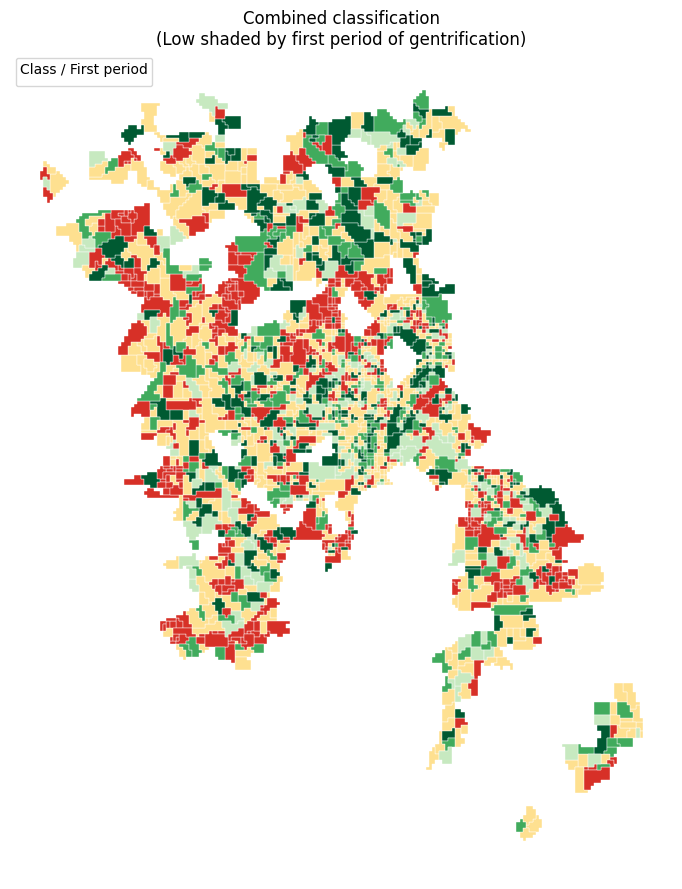

In [8]:
# Green gradient: darker = earlier first classification as Low
period_green = {
    '1990_2000': '#005a32',
    '2000_2010': '#41ab5d',
    '2010_2020': '#c7e9c0',
}

fig, ax = plt.subplots(figsize=(9, 9))

# Non-Low classes first (background)
for cls, color in [('Medium', '#fee090'), ('High', '#d73027')]:
    subset = combined_gdf[combined_gdf['combined_class'] == cls]
    if not subset.empty:
        subset.plot(ax=ax, color=color, label=cls, edgecolor='white', linewidth=0.3)

# Low class: shade by first_low_period
for period, color in period_green.items():
    subset = combined_gdf[
        (combined_gdf['combined_class'] == 'Low') &
        (combined_gdf['first_low_period'] == period)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=color,
                    label=f'Low — first in {period.replace("_", "–")}',
                    edgecolor='white', linewidth=0.3)

ax.set_title('Combined classification\n(Low shaded by first period of gentrification)')
ax.legend(title='Class / First period', loc='upper left', fontsize=8)
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 5-year quantile-based combined label

Builds an alternative combined label using all 6 five-year overlay periods and within-period tertile ranking.

**Why:** The 10-year σ-band approach produces unstable class boundaries at finer temporal resolution because the absolute distribution mean shifts period to period. Tertile ranking is stable — it always produces equal-N classes regardless of those shifts, and mean-rank aggregation replaces the hard "ever class 0 = locked forever" rule so that neighborhood trajectories across all 6 periods contribute to the final label.

**Steps:**
1. Load all 6 five-year overlay GeoPackages → long-format `(cluster_id, period, mean_score)`
2. Within each period: assign tertile rank 0/1/2 via `pd.qcut`
3. Per cluster: compute `mean_rank` = average rank across 6 periods
4. Cut `mean_rank` into 3 final classes by its own tertile boundaries
5. Save to `classified_combined_5yr_quantile.gpkg`

In [9]:
# Cell Q1: Load all 6 five-year overlay GeoPackages → long-format DataFrame
import fiona

PERIODS_5Y = [
    '1990_1995', '1995_2000', '2000_2005',
    '2005_2010', '2010_2015', '2015_2020',
]

records_5y = []
missing_periods = []

for period in PERIODS_5Y:
    gpkg_path = OVERLAY_DIR / f'weighted_overlay_clusters_{period}.gpkg'
    if not gpkg_path.exists():
        print(f'[SKIP] {period}: file not found')
        missing_periods.append(period)
        continue

    layers = fiona.listlayers(str(gpkg_path))
    gdf_p = gpd.read_file(str(gpkg_path), layer=layers[0])

    # Normalise column name: '_mean' → 'mean'
    if '_mean' in gdf_p.columns and 'mean' not in gdf_p.columns:
        gdf_p = gdf_p.rename(columns={'_mean': 'mean'})

    if 'mean' not in gdf_p.columns:
        raise KeyError(f"Period {period}: column 'mean' not found. Columns: {list(gdf_p.columns)}")

    # Detect join key
    if 'munic_clus' in gdf_p.columns:
        jk = 'munic_clus'
    elif 'cluster_id' in gdf_p.columns:
        jk = 'cluster_id'
    else:
        raise KeyError(f"Period {period}: no munic_clus or cluster_id column found")

    for _, row in gdf_p[[jk, 'mean']].iterrows():
        records_5y.append({
            'cluster_id': str(row[jk]),
            'period':     period,
            'mean_score': float(row['mean']) if pd.notna(row['mean']) else np.nan,
        })

df_5y = pd.DataFrame(records_5y)
n_clusters = df_5y['cluster_id'].nunique()
n_periods  = df_5y['period'].nunique()
print(f"Loaded {len(df_5y):,} rows | {n_clusters} unique clusters | {n_periods} periods")
if missing_periods:
    print(f"Missing periods (skipped): {missing_periods}")
df_5y.head()

Loaded 13,392 rows | 2232 unique clusters | 6 periods


,cluster_id,period,mean_score
0,101_1,1990_1995,4.292237
1,101_2,1990_1995,3.818727
2,101_3,1990_1995,3.168778
3,101_4,1990_1995,3.944019
4,101_5,1990_1995,2.658947


In [10]:
# Cell Q2: Within-period tertile ranking + cross-period mean-rank aggregation

# ── Step 1: Within-period tertile rank (0=low, 1=mid, 2=high) ──
# pd.qcut with q=3 always produces equal-N groups regardless of absolute score shifts.
# NaN scores are excluded from the cut and receive NaN rank.
df_5y['period_rank'] = np.nan

for period in PERIODS_5Y:
    mask = df_5y['period'] == period
    scores = df_5y.loc[mask, 'mean_score']
    valid  = scores.notna()
    if valid.sum() < 3:
        print(f"[WARN] {period}: only {valid.sum()} valid scores, skipping tertile cut")
        continue
    # duplicates='drop' handles tied boundary values gracefully
    df_5y.loc[mask & valid, 'period_rank'] = pd.qcut(
        scores[valid], q=3, labels=[0, 1, 2], duplicates='drop'
    ).astype(float)

print("Per-period tertile rank distribution:")
print(df_5y.groupby(['period', 'period_rank']).size().unstack(fill_value=0).to_string())

# ── Step 2: Per-cluster mean rank across all 6 periods ──
agg_5y = (
    df_5y.groupby('cluster_id')['period_rank']
    .agg(mean_rank='mean', n_periods_with_data='count',
         n_low_periods=lambda x: (x == 0).sum())
    .reset_index()
)

# ── Step 3: Cut mean_rank into 3 final classes by its own tertile boundaries ──
# This ensures the final label distribution is balanced (~1/3 each).
valid_rank = agg_5y['mean_rank'].notna()
agg_5y['combined_class_idx'] = np.nan

agg_5y.loc[valid_rank, 'combined_class_idx'] = pd.qcut(
    agg_5y.loc[valid_rank, 'mean_rank'], q=3, labels=[0, 1, 2], duplicates='drop'
).astype(float).astype('Int64')

label_map_q = {0: 'Low (gentrified)', 1: 'Medium', 2: 'High'}
agg_5y['combined_class'] = agg_5y['combined_class_idx'].map(label_map_q)

# ── Step 4: First-low-period (earliest period where rank == 0) for map shading ──
first_low_5y = (
    df_5y[df_5y['period_rank'] == 0]
    .groupby('cluster_id')['period']
    .min()
    .reset_index()
    .rename(columns={'period': 'first_low_period'})
)
agg_5y = agg_5y.merge(first_low_5y, on='cluster_id', how='left')

print(f"\nAggregated {len(agg_5y)} clusters")
print(f"\nFinal combined_class_idx distribution:")
print(agg_5y['combined_class_idx'].value_counts().sort_index())
print(f"\nMean rank range: {agg_5y['mean_rank'].min():.3f} – {agg_5y['mean_rank'].max():.3f}")
agg_5y.head()

Per-period tertile rank distribution:
period_rank  0.0  1.0  2.0
period                    
1990_1995    744  744  744
1995_2000    744  744  744
2000_2005    744  744  744
2005_2010    744  744  744
2010_2015    744  744  744
2015_2020    744  744  744

Aggregated 2232 clusters

Final combined_class_idx distribution:
combined_class_idx
0.0    954
1.0    734
2.0    544
Name: count, dtype: int64

Mean rank range: 0.000 – 2.000


,cluster_id,mean_rank,n_periods_with_data,n_low_periods,combined_class_idx,combined_class,first_low_period
0,101_1,0.833333,6,3,0.0,Low (gentrified),1995_2000
1,101_10,0.833333,6,3,0.0,Low (gentrified),1995_2000
2,101_100,1.666667,6,0,2.0,High,NaN
3,101_1000,1.000000,6,2,1.0,Medium,1990_1995
4,101_1001,1.333333,6,2,2.0,High,1995_2000


In [ ]:
# Cell Q3: Merge onto base geometry, save, and compare against existing label

# base_gdf and join_key are already defined in the kernel from the section above
combined_5y_gdf = base_gdf.merge(
    agg_5y[['cluster_id', 'mean_rank', 'n_low_periods', 'n_periods_with_data',
            'combined_class_idx', 'combined_class', 'first_low_period']],
    left_on=join_key, right_on='cluster_id', how='left'
)

out_path_5y = CLASSIFIED_DIR / 'classified_combined_5yr_quantile.gpkg'
combined_5y_gdf.to_file(str(out_path_5y), driver='GPKG')
print(f"Saved → {out_path_5y}")
print(f"  Rows: {len(combined_5y_gdf)} | Columns: {list(combined_5y_gdf.columns)}")

# ── Comparison against existing 10-year combined label ──
existing_path = CLASSIFIED_DIR / 'classified_combined.gpkg'
existing_gdf  = gpd.read_file(str(existing_path))[[join_key, 'combined_class_idx']].rename(
    columns={'combined_class_idx': 'class_10yr'}
)

comp = combined_5y_gdf[[join_key, 'combined_class_idx']].rename(
    columns={'combined_class_idx': 'class_5yr'}
).merge(existing_gdf, on=join_key, how='inner')

comp['class_5yr']  = comp['class_5yr'].astype('Int64')
comp['class_10yr'] = comp['class_10yr'].astype('Int64')
agreement = (comp['class_5yr'] == comp['class_10yr']).mean()

print(f"\nAgreement with 10-year label: {agreement:.1%}  ({int(agreement * len(comp))}/{len(comp)} clusters)")
print("\nNew 5yr-quantile class distribution:")
print(combined_5y_gdf['combined_class_idx'].value_counts().sort_index())
print("\nExisting 10yr class distribution:")
print(existing_gdf['class_10yr'].value_counts().sort_index())

# Cross-tabulation
print("\nCross-tab (rows=5yr-quantile, cols=10yr-σband):")
print(pd.crosstab(comp['class_5yr'], comp['class_10yr'], margins=True))

Saved → ..\data\processed\classified_gt\classified_combined_5yr_quantile.gpkg
  Rows: 2232 | Columns: ['area', 'cluster_id', 'id_munic', 'munic_code', 'geometry', 'mean_rank', 'n_low_periods', 'n_periods_with_data', 'combined_class_idx', 'combined_class', 'first_low_period']

Agreement with 10-year label: 46.4%  (1035/2232 clusters)

New 5yr-quantile class distribution:
combined_class_idx
0.0    954
1.0    734
2.0    544
Name: count, dtype: int64

Existing 10yr class distribution:
class_10yr
0    871
1    744
2    617
Name: count, dtype: int64

Cross-tab (rows=5yr-quantile, cols=10yr-σband):
class_10yr    0    1    2   All
class_5yr                      
0           466  354  134   954
1           286  267  181   734
2           119  123  302   544
All         871  744  617  2232


: 